- Load dataset
- get example
- display blank grid
- display heatmap random + cheating
- display heatmap - blank

In [1]:
import os
import torch
import matplotlib.pyplot as plt

from compactreasoningmodels.solving_traces.random import RandomSolver
from compactreasoningmodels.solving_traces.cheating_random import CheatingRandom
from compactreasoningmodels.solving_traces.arc_consistency import ArcConsistency
from compactreasoningmodels.datasets.jsonl import JsonlDataset
from compactreasoningmodels.utils.display import display_grid
os.environ["DATA_DIR"] = "../data/"

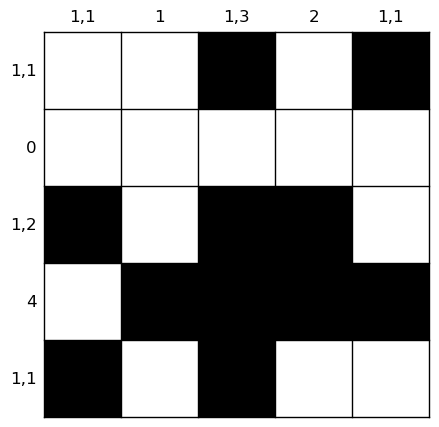

In [2]:
dataset = JsonlDataset("raw/nonogram_5x5_small.jsonl", target_shape=(5, 5))
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False) 
sample_clues, sample_grids = next(iter(dataloader))
sample_clues = sample_clues.squeeze(0).reshape(2, 5, 3)
sample_grids = sample_grids.squeeze(0)
fig, ax = plt.subplots(figsize=(5, 5))
display_grid(ax, sample_grids, clues=sample_clues, title='')

[[0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5]]
[[0.48 0.48 0.52 0.48 0.52]
 [0.48 0.48 0.48 0.48 0.48]
 [0.52 0.48 0.52 0.52 0.48]
 [0.48 0.52 0.52 0.52 0.52]
 [0.52 0.48 0.52 0.48 0.48]]
[[0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5]]


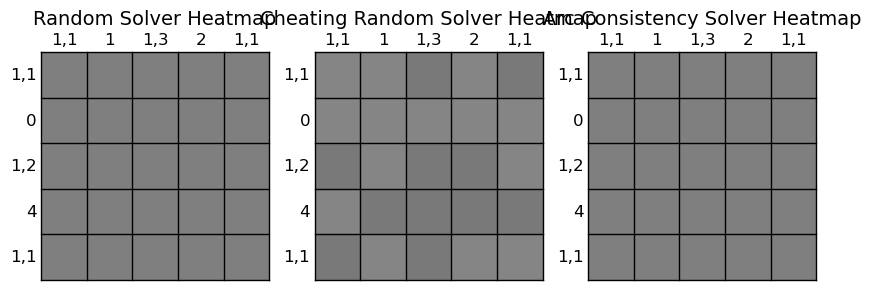

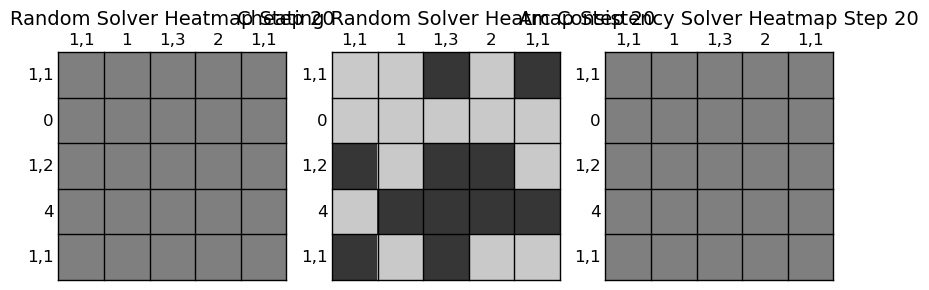

In [5]:
blank_grid = torch.full_like(sample_grids, 0.5)
random_solver = RandomSolver(sample_clues, (5,5))
cheating_solver = CheatingRandom(sample_clues, (5,5))
arc_consistency_solver = ArcConsistency(sample_clues, (5,5))
cheating_solver.set_correct(sample_grids.numpy())
random_heatmap = random_solver.heatmap_step(blank_grid.numpy())
cheating_heatmap = cheating_solver.heatmap_step(blank_grid.numpy())
arc_consistency_heatmap = arc_consistency_solver.heatmap_step(blank_grid.numpy())
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
display_grid(axes[0], random_heatmap, clues=sample_clues, title='Random Solver Heatmap')
display_grid(axes[1], cheating_heatmap, clues=sample_clues, title='Cheating Random Solver Heatmap')
display_grid(axes[2], arc_consistency_heatmap, clues=sample_clues, title='Arc Consistency Solver Heatmap')
print(random_heatmap)
print(cheating_heatmap)
print(arc_consistency_heatmap)
prev_heatmap = cheating_heatmap
for i in range(20):
    cheating_heatmap = cheating_solver.heatmap_step(prev_heatmap)
    prev_heatmap = cheating_heatmap
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
display_grid(axes[0], random_heatmap, clues=sample_clues, title=f'Random Solver Heatmap Step {i+1}')
display_grid(axes[1], cheating_heatmap, clues=sample_clues, title=f'Cheating Random Solver Heatmap Step {i+1}')
display_grid(axes[2], arc_consistency_heatmap, clues=sample_clues, title=f'Arc Consistency Solver Heatmap Step {i+1}')

False [[0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 1. ]
 [0.5 0.5 0.5 0.5 0.5]]
False [[0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 1.  0.5]
 [0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5]]


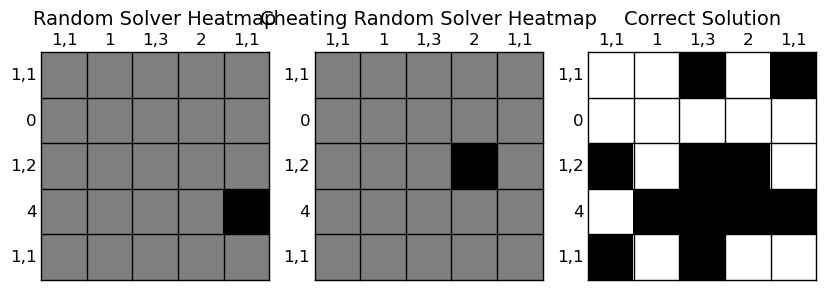

In [8]:
random_grid = torch.rand(sample_grids.shape) * 0.5
random_solver = RandomSolver(sample_clues, (5,5))
cheating_solver = CheatingRandom(sample_clues, (5,5))
arc_consistency_solver = ArcConsistency(sample_clues, (5,5))
cheating_solver.set_correct(sample_grids.numpy())
random_success, random_traces = random_solver.try_solve(max_steps=1)
cheating_success, cheating_traces = cheating_solver.try_solve(max_steps=1)
arc_consistency_success, arc_consistency_traces = arc_consistency_solver.try_solve(max_steps=1)
random_output = random_traces[-1]
cheating_output = cheating_traces[-1]
arc_consistency_output = arc_consistency_traces[-1]
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
display_grid(axes[0], random_output, clues=sample_clues, title='Random Solver Heatmap')
display_grid(axes[1], cheating_output, clues=sample_clues, title='Cheating Random Solver Heatmap')
display_grid(axes[2], sample_grids.numpy(), clues=sample_clues, title='Correct Solution')
print(random_success, random_output)
print(cheating_success, cheating_output)